# Control Collapse Experiments


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import deque
import random
from tqdm import tqdm
import warnings
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#00BCD4']

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


/home/sans/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using device: cpu


In [2]:
class Custom1DToyEnv:
    """
    1D Navigation task. 
    State: [position, velocity] (2-dim)
    Action: [force] in [-1, 1] (1-dim)
    Reward: -(x^2 + 0.1*v^2 + 0.01*u^2)
    Optimal policy reaches x=0, v=0 and stays there.
    """
    def __init__(self, seed=None):
        self.state_dim = 2
        self.action_dim = 1
        self.action_low = -1.0
        self.action_high = 1.0
        self.seed = seed
        self.dt = 0.1
        self.friction = 0.1
        self.state = np.zeros(2, dtype=np.float32)
        if seed is not None:
            np.random.seed(seed)
            
    def reset(self):
        # Start randomly between -5 and 5
        x = np.random.uniform(-5.0, 5.0)
        v = np.random.uniform(-1.0, 1.0)
        self.state = np.array([x, v], dtype=np.float32)
        return self.state.copy()

    def step(self, action):
        action = np.clip(action, self.action_low, self.action_high)
        if isinstance(action, (int, float)):
            action = np.array([action])
        force = action[0]
        
        x, v = self.state
        v_next = v + (force - self.friction * v) * self.dt
        x_next = x + v_next * self.dt
        
        self.state = np.array([x_next, v_next], dtype=np.float32)
        reward = -(x_next**2 + 0.1 * v_next**2 + 0.01 * force**2)
        done = False 
        
        return self.state.copy(), float(reward), done, {}

    def sample_action(self):
        return np.random.uniform(self.action_low, self.action_high, size=(1,))

env = Custom1DToyEnv(seed=0)
s = env.reset()
print(f'State dim: {env.state_dim}, Action dim: {env.action_dim}')
print(f'Initial state: {s}')
s2, r, done, _ = env.step(np.array([0.5]))
print(f'After action [0.5]: state={s2}, reward={r:.4f}')


State dim: 2, Action dim: 1
Initial state: [0.48813504 0.43037874]
After action [0.5]: state=[0.5357425  0.47607493], reward=-0.3122


In [3]:
class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s_next):
        self.buffer.append((s.copy(), a.copy(), r, s_next.copy()))

    def sample(self, batch_size):
        if len(self.buffer) == 0:
            return None, None, None, None
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        s, a, r, s2 = zip(*batch)
        return (
            torch.FloatTensor(np.array(s)).to(DEVICE),
            torch.FloatTensor(np.array(a)).to(DEVICE),
            torch.FloatTensor(np.array(r)).unsqueeze(1).to(DEVICE),
            torch.FloatTensor(np.array(s2)).to(DEVICE)
        )

    def __len__(self):
        return len(self.buffer)


In [4]:
class WorldModel(nn.Module):
    def __init__(self, state_dim=2, action_dim=1, hidden_dim=128):
        super().__init__()
        in_dim = state_dim + action_dim
        self.backbone = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
        )
        self.state_mean  = nn.Linear(hidden_dim, state_dim)
        self.state_logstd = nn.Linear(hidden_dim, state_dim)
        self.reward_mean  = nn.Linear(hidden_dim, 1)
        self.reward_logstd = nn.Linear(hidden_dim, 1)

    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)
        h = self.backbone(x)
        s_mean = self.state_mean(h)
        s_std  = torch.exp(self.state_logstd(h).clamp(-4, 2))
        r_mean = self.reward_mean(h)
        r_std  = torch.exp(self.reward_logstd(h).clamp(-4, 2))
        return s_mean, s_std, r_mean, r_std

    def sample(self, s, a):
        with torch.no_grad():
            s_mean, s_std, r_mean, r_std = self.forward(s, a)
            s_next = Normal(s_mean, s_std).sample()
            r      = Normal(r_mean, r_std).sample()
        return s_next, r

    def nll_loss(self, s, a, s_next_true, r_true):
        s_mean, s_std, r_mean, r_std = self.forward(s, a)
        s_nll = -Normal(s_mean, s_std).log_prob(s_next_true).sum(-1).mean()
        r_nll = -Normal(r_mean, r_std).log_prob(r_true).sum(-1).mean()
        return s_nll + r_nll

    def predictive_variance(self, states, actions):
        with torch.no_grad():
            _, s_std, _, r_std = self.forward(states, actions)
        return (s_std.mean() + r_std.mean()).item()

def build_world_model():
    m = WorldModel().to(DEVICE)
    return m, optim.Adam(m.parameters(), lr=1e-3)


In [5]:
class Actor(nn.Module):
    def __init__(self, state_dim=2, action_dim=1, hidden_dim=128, action_scale=1.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.mean_head   = nn.Linear(hidden_dim, action_dim)
        self.logstd_head = nn.Linear(hidden_dim, action_dim)
        self.action_scale = action_scale

    def forward(self, s):
        h = self.net(s)
        mean   = self.action_scale * torch.tanh(self.mean_head(h))
        logstd = self.logstd_head(h).clamp(-3, 1)
        return mean, logstd.exp()

    def act(self, s_np):
        s = torch.FloatTensor(s_np).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            mean, std = self.forward(s)
            action = Normal(mean, std).sample()
            action = action.clamp(-self.action_scale, self.action_scale)
        return action.cpu().numpy().flatten()

    def action_entropy(self, s):
        _, std = self.forward(s)
        return Normal(torch.zeros_like(std), std).entropy().mean()

class Critic(nn.Module):
    def __init__(self, state_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, s):
        return self.net(s)

def build_actor_critic():
    actor  = Actor().to(DEVICE)
    critic = Critic().to(DEVICE)
    opt_a  = optim.Adam(actor.parameters(),  lr=3e-4)
    opt_c  = optim.Adam(critic.parameters(), lr=1e-3)
    return actor, critic, opt_a, opt_c


In [6]:
def get_seed_states(real_buffer, model_buffer, prob_real, batch_size):
    """
    Determine seed states based on mixing probabilities.
    """
    sources = []
    probs = []
    
    if prob_real > 0 and len(real_buffer) >= batch_size:
        sources.append(real_buffer)
        probs.append(prob_real)
        
    if (1 - prob_real) > 0 and len(model_buffer) >= batch_size:
        sources.append(model_buffer)
        probs.append(1 - prob_real)
        
    if not sources:
        # Fallback to whatever buffer has data if mixing is impossible due to size
        if len(real_buffer) >= batch_size: return real_buffer.sample(batch_size)[0]
        if len(model_buffer) >= batch_size: return model_buffer.sample(batch_size)[0]
        return None
        
    probs = np.array(probs) / sum(probs)
    chosen_buffer = np.random.choice(sources, p=probs)
    s, _, _, _ = chosen_buffer.sample(batch_size)
    return s

def multi_step_imagination(world_model, actor, seed_states, H, model_buffer):
    """
    Roll out H steps from seed states using the world model and current actor.
    Pushes generated transitions to the model_buffer.
    Returns aggregated transitions for policy update.
    """
    s = seed_states
    all_s, all_a, all_r, all_sn = [], [], [], []
    
    for _ in range(H):
        with torch.no_grad():
            a_mean, a_std = actor(s)
            a = Normal(a_mean, a_std).sample().clamp(-1, 1)
        
        s_next, r = world_model.sample(s, a)
        
        all_s.append(s)
        all_a.append(a)
        all_r.append(r)
        all_sn.append(s_next)
        
        # Push to model buffer
        # In a real batched setup, we'd add individual transitions, but for speed we just store them.
        for i in range(s.size(0)):
            model_buffer.push(
                s[i].cpu().numpy(), 
                a[i].cpu().numpy(), 
                r[i].item(), 
                s_next[i].cpu().numpy()
            )
        s = s_next
        
    # Pool all transitions for 1-step TD update
    return torch.cat(all_s), torch.cat(all_a), torch.cat(all_r), torch.cat(all_sn)

def get_real_tuples(env, actor, n_steps=64):
    transitions = []
    s = env.reset()
    for _ in range(n_steps):
        a = actor.act(s)
        s_next, r, done, _ = env.step(a)
        transitions.append((s, a, r, s_next))
        s = env.reset() if done else s_next
    s_t = torch.FloatTensor(np.array([t[0] for t in transitions])).to(DEVICE)
    a_t = torch.FloatTensor(np.array([t[1] for t in transitions])).to(DEVICE)
    r_t = torch.FloatTensor(np.array([t[2] for t in transitions])).unsqueeze(1).to(DEVICE)
    sn_t= torch.FloatTensor(np.array([t[3] for t in transitions])).to(DEVICE)
    return s_t, a_t, r_t, sn_t

def mix_batches(sources, probs, batch_size):
    assert abs(sum(probs) - 1.0) < 1e-5
    counts = np.random.multinomial(batch_size, probs)
    parts = []
    for (s, a, r, sn), n in zip(sources, counts):
        if n == 0: continue
        idx = torch.randint(0, s.shape[0], (n,))
        parts.append((s[idx], a[idx], r[idx], sn[idx]))
    if not parts: return None, None, None, None
    s  = torch.cat([p[0] for p in parts])
    a  = torch.cat([p[1] for p in parts])
    r  = torch.cat([p[2] for p in parts])
    sn = torch.cat([p[3] for p in parts])
    return s, a, r, sn


In [7]:
def evaluate_policy(actor, n_episodes=10, seed=0):
    env_eval = Custom1DToyEnv(seed=seed)
    returns = []
    for _ in range(n_episodes):
        s = env_eval.reset()
        ep_r = 0.0
        for _ in range(200):
            a = actor.act(s)
            s, r, done, _ = env_eval.step(a)
            ep_r += r
            if done: break
        returns.append(ep_r)
    return np.mean(returns), np.std(returns)

def compute_model_variance(world_model, real_buffer, n=256):
    s, a, r, sn = real_buffer.sample(n)
    if s is None: return float('nan')
    return world_model.predictive_variance(s, a)

def compute_model_error(world_model, real_buffer, n=256):
    s, a, r, sn = real_buffer.sample(n)
    if s is None: return float('nan')
    with torch.no_grad():
        loss = world_model.nll_loss(s, a, sn, r)
    return loss.item()

def compute_reward_entropy_v2(world_model, real_buffer, n=512, bins=20):
    s, a, r, sn = real_buffer.sample(n)
    if s is None: return float('nan')
    with torch.no_grad():
        x = torch.cat([s, a], -1)
        h = world_model.backbone(x)
        r_mean = world_model.reward_mean(h)
        r_logstd = world_model.reward_logstd(h)
        r_std = r_logstd.exp().clamp(1e-4)
        r_samples = Normal(r_mean, r_std).sample([20]).cpu().numpy().flatten()
    hist, _ = np.histogram(r_samples, bins=bins, density=True)
    hist = hist + 1e-10
    hist /= hist.sum()
    return float(scipy_entropy(hist))

def compute_policy_entropy(actor, real_buffer, n=256):
    s, _, _, _ = real_buffer.sample(n)
    if s is None: return float('nan')
    with torch.no_grad():
        ent = actor.action_entropy(s)
    return ent.item()

def compute_imagined_vs_real_reward_gap(world_model, actor, env, n=64):
    real_rewards = []
    s = env.reset()
    for _ in range(n):
        a = actor.act(s)
        s_next, r, done, _ = env.step(a)
        real_rewards.append(r)
        s = env.reset() if done else s_next

    s_t = torch.FloatTensor(np.array([env.reset() for _ in range(n)])).to(DEVICE)
    with torch.no_grad():
        a_mean, a_std = actor(s_t)
        a_t = Normal(a_mean, a_std).sample().clamp(-1, 1)
        h = world_model.backbone(torch.cat([s_t, a_t], -1))
        r_imag = world_model.reward_mean(h).cpu().numpy().flatten()

    return np.mean(r_imag) - np.mean(real_rewards)


In [8]:
def train_agent(
    a=1.0, b=0.0, c=1.0,
    a_prime=0.0, b_prime=1.0, c_prime=0.0,
    n_iterations=300, batch_size=128, eval_every=25,
    wm_updates_per_iter=5, policy_updates_per_iter=5,
    real_steps_per_iter=32, warmup_steps=500, H=15,
    seed=42, verbose=True, label='run'
):
    assert abs(b + c - 1.0) < 1e-5, 'b + c must equal 1'
    assert abs(b_prime + c_prime - 1.0) < 1e-5, 'b_prime + c_prime must equal 1'

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    env = Custom1DToyEnv(seed=seed)
    world_model, opt_wm = build_world_model()
    actor, critic, opt_a, opt_c = build_actor_critic()
    
    real_buffer = ReplayBuffer(capacity=50000)
    model_buffer = ReplayBuffer(capacity=50000)

    # Warmup
    s = env.reset()
    for step_idx in range(warmup_steps):
        a_rand = env.sample_action()
        s_next, r, done, _ = env.step(a_rand)
        real_buffer.push(s, a_rand.flatten(), r, s_next)
        
        # We also need an initial seed for the model buffer so it's not empty!
        # We simulate a 1-step random transition using the true env's initial states.
        # But wait, to strictly avoid real transitions, we sample a state from reset,
        # randomly act, and use the world model.
        if step_idx % 50 == 0:
            s_init_mb = torch.FloatTensor(env.reset()).unsqueeze(0).to(DEVICE)
            a_init_mb = torch.FloatTensor(env.sample_action()).unsqueeze(0).to(DEVICE)
            sn_mb, r_mb = world_model.sample(s_init_mb, a_init_mb)
            model_buffer.push(s_init_mb[0].cpu().numpy(), a_init_mb[0].cpu().numpy(), r_mb.item(), sn_mb[0].cpu().numpy())
            
        s = env.reset() if done else s_next

    logs = {
        'iteration': [], 'eval_return': [], 'eval_return_std': [],
        'wm_variance': [], 'wm_nll': [], 'reward_entropy': [],
        'policy_entropy': [], 'imag_real_gap': [],
        'wm_train_loss': [], 'policy_train_loss': [],
    }

    for iteration in tqdm(range(n_iterations), desc=label, leave=True, disable=not verbose):
        # Phase 1: Real experience
        s = env.reset()
        for _ in range(real_steps_per_iter):
            act_np = actor.act(s)
            s_next, r, done, _ = env.step(act_np)
            real_buffer.push(s, act_np, r, s_next)
            s = env.reset() if done else s_next

        # Phase 2: World Model Update
        wm_losses = []
        for _ in range(wm_updates_per_iter):
            prob_real   = a
            prob_synth  = (1 - a) * b
            prob_replay = (1 - a) * c

            sources, probs_list = [], []

            if prob_real > 0:
                rs, ra, rr, rsn = get_real_tuples(env, actor, n_steps=batch_size)
                sources.append((rs, ra, rr, rsn))
                probs_list.append(prob_real)

            if prob_synth > 0:
                # Generate new synthetic data
                seed_s = get_seed_states(real_buffer, model_buffer, prob_real, batch_size)
                if seed_s is not None:
                    a_rand = (torch.rand(batch_size, 1).to(DEVICE) * 2 - 1)
                    sn_hat, r_hat = world_model.sample(seed_s, a_rand)
                    sources.append((seed_s, a_rand, r_hat, sn_hat))
                    probs_list.append(prob_synth)

            if prob_replay > 0 and len(model_buffer) >= batch_size:
                ms, ma, mr, msn = model_buffer.sample(batch_size)
                sources.append((ms, ma, mr, msn))
                probs_list.append(prob_replay)

            if not sources: continue

            probs_arr = np.array(probs_list)
            probs_arr /= probs_arr.sum()
            s_b, a_b, r_b, sn_b = mix_batches(sources, probs_arr, batch_size)

            if s_b is None: continue

            opt_wm.zero_grad()
            loss_wm = world_model.nll_loss(s_b, a_b, sn_b, r_b)
            loss_wm.backward()
            torch.nn.utils.clip_grad_norm_(world_model.parameters(), 1.0)
            opt_wm.step()
            wm_losses.append(loss_wm.item())

        # Phase 3: Policy Update
        policy_losses = []
        for _ in range(policy_updates_per_iter):
            prob_real_p   = a_prime
            prob_synth_p  = (1 - a_prime) * b_prime
            prob_replay_p = (1 - a_prime) * c_prime

            sources_p, probs_p = [], []

            if prob_real_p > 0:
                r_s, r_a, r_r, r_sn = get_real_tuples(env, actor, n_steps=batch_size)
                sources_p.append((r_s, r_a, r_r, r_sn))
                probs_p.append(prob_real_p)

            if prob_synth_p > 0:
                # Multi-step imagination
                seed_s = get_seed_states(real_buffer, model_buffer, prob_real_p, batch_size)
                if seed_s is not None:
                    im_s, im_a, im_r, im_sn = multi_step_imagination(
                        world_model, actor, seed_s, H, model_buffer)
                    sources_p.append((im_s, im_a, im_r, im_sn))
                    probs_p.append(prob_synth_p)

            if prob_replay_p > 0 and len(model_buffer) >= batch_size:
                rep_s, rep_a, rep_r, rep_sn = model_buffer.sample(batch_size)
                sources_p.append((rep_s, rep_a, rep_r, rep_sn))
                probs_p.append(prob_replay_p)

            if not sources_p: continue

            probs_p_arr = np.array(probs_p)
            probs_p_arr /= probs_p_arr.sum()
            s_p, a_p, r_p, sn_p = mix_batches(sources_p, probs_p_arr, batch_size)
            
            if s_p is None: continue

            gamma = 0.99
            with torch.no_grad():
                target = r_p + gamma * critic(sn_p)
            value = critic(s_p)
            critic_loss = F.mse_loss(value, target)
            opt_c.zero_grad()
            critic_loss.backward()
            opt_c.step()

            advantage = (target - value.detach()).squeeze(1)
            a_mean_p, a_std_p = actor(s_p)
            log_prob = Normal(a_mean_p, a_std_p).log_prob(a_p).sum(-1)
            actor_loss = -(log_prob * advantage).mean()
            entropy_bonus = actor.action_entropy(s_p)
            actor_loss = actor_loss - 0.01 * entropy_bonus
            opt_a.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor.parameters(), 0.5)
            opt_a.step()

            policy_losses.append(actor_loss.item())

        if iteration % eval_every == 0:
            ret_mean, ret_std = evaluate_policy(actor, n_episodes=10)
            wm_var  = compute_model_variance(world_model, real_buffer)
            wm_nll  = compute_model_error(world_model, real_buffer)
            r_ent   = compute_reward_entropy_v2(world_model, real_buffer)
            p_ent   = compute_policy_entropy(actor, real_buffer)
            gap     = compute_imagined_vs_real_reward_gap(world_model, actor, env, n=64)

            logs['iteration'].append(iteration)
            logs['eval_return'].append(ret_mean)
            logs['eval_return_std'].append(ret_std)
            logs['wm_variance'].append(wm_var)
            logs['wm_nll'].append(wm_nll)
            logs['reward_entropy'].append(r_ent)
            logs['policy_entropy'].append(p_ent)
            logs['imag_real_gap'].append(gap)
            logs['wm_train_loss'].append(np.mean(wm_losses) if wm_losses else float('nan'))
            logs['policy_train_loss'].append(np.mean(policy_losses) if policy_losses else float('nan'))

            if verbose:
                print(f'  Iter {iteration:4d} | Return: {ret_mean:7.1f} ± {ret_std:.1f} | '
                      f'WM-var: {wm_var:.4f} | π-ent: {p_ent:.3f} | Gap: {gap:.2f}')

    return logs, world_model, actor


In [9]:
CONFIGS = [
    dict(
        label='Baseline (Real Only)',
        a=1.0, b=0.0, c=1.0,
        a_prime=1.0, b_prime=0.0, c_prime=1.0,
        color=PALETTE[0],
        linestyle='-',
    ),
    dict(
        label='Dreamer (a=1, a′=0)',
        a=1.0, b=0.0, c=1.0,
        a_prime=0.0, b_prime=1.0, c_prime=0.0,
        color=PALETTE[1],
        linestyle='-',
    ),
    dict(
        label='Partial Excitation (a=0.3, a′=0.5)',
        a=0.3, b=0.7, c=0.3,
        a_prime=0.5, b_prime=1.0, c_prime=0.0,
        color=PALETTE[4],
        linestyle=':',
    ),
    dict(
        label='Full Collapse (a=0, a′=0)',
        a=0.0, b=1.0, c=0.0,
        a_prime=0.0, b_prime=1.0, c_prime=0.0,
        color=PALETTE[5],
        linestyle=':',
    ),
]

for cfg in CONFIGS:
    print(f"{cfg['label']:40s} a={cfg['a']:.1f} a′={cfg['a_prime']:.1f}")


Baseline (Real Only)                     a=1.0 a′=1.0
Dreamer (a=1, a′=0)                      a=1.0 a′=0.0
Partial Excitation (a=0.3, a′=0.5)       a=0.3 a′=0.5
Full Collapse (a=0, a′=0)                a=0.0 a′=0.0


In [10]:
N_ITERATIONS = 300
EVAL_EVERY   = 10
BATCH_SIZE   = 128
H_STEPS      = 15

all_results = {}

for cfg in CONFIGS:
    label = cfg['label']
    print(f'Running: {label}')
    logs, wm, actor = train_agent(
        a=cfg['a'], b=cfg['b'], c=cfg['c'],
        a_prime=cfg['a_prime'], b_prime=cfg['b_prime'], c_prime=cfg['c_prime'],
        n_iterations=N_ITERATIONS,
        batch_size=BATCH_SIZE,
        eval_every=EVAL_EVERY,
        wm_updates_per_iter=4,
        policy_updates_per_iter=4,
        real_steps_per_iter=32,
        warmup_steps=500,
        H=H_STEPS,
        seed=42,
        verbose=True,
        label=label
    )
    all_results[label] = {
        'logs': logs,
        'world_model': wm,
        'actor': actor,
        'color': cfg['color'],
        'linestyle': cfg['linestyle'],
        'cfg': cfg
    }


Running: Baseline (Real Only)


Baseline (Real Only):   0%|          | 1/300 [00:01<05:59,  1.20s/it]

  Iter    0 | Return: -2121.6 ± 1648.8 | WM-var: 2.5875 | π-ent: 1.755 | Gap: 14.30


Baseline (Real Only):   4%|▎         | 11/300 [00:05<02:03,  2.33it/s]

  Iter   10 | Return: -1172.6 ± 1103.5 | WM-var: 4.8173 | π-ent: 2.315 | Gap: 15.97


...

Full Collapse (a=0, a′=0):  94%|█████████▍| 282/300 [01:28<00:04,  3.75it/s]

  Iter  280 | Return: -12295.8 ± 6657.6 | WM-var: 2.1550 | π-ent: 0.795 | Gap: 47.56


Full Collapse (a=0, a′=0):  97%|█████████▋| 291/300 [01:31<00:03,  2.89it/s]

  Iter  290 | Return: -2590.9 ± 1426.8 | WM-var: 1.7293 | π-ent: 0.973 | Gap: 27.21


Full Collapse (a=0, a′=0): 100%|██████████| 300/300 [01:33<00:00,  3.22it/s]


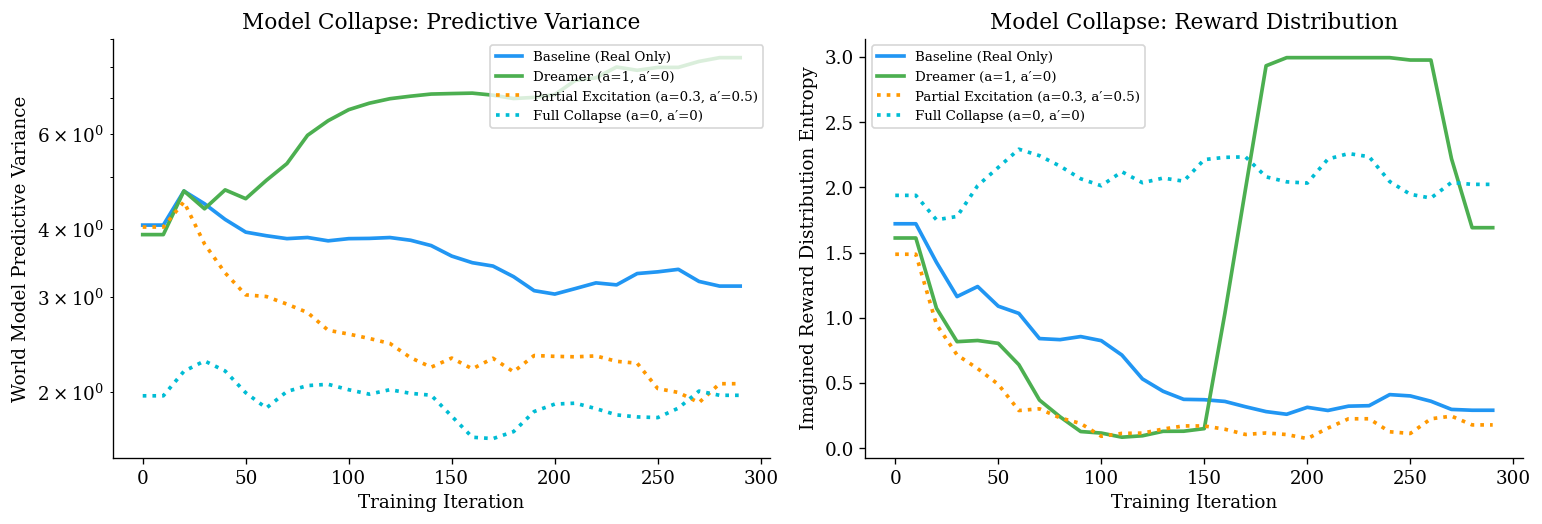

In [11]:
def smooth(y, box_pts=3):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='valid')
    # Pad to original length
    return np.pad(y_smooth, (box_pts//2, box_pts//2 + (len(y) - len(y_smooth) - box_pts//2*2)), mode='edge')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for label, res in all_results.items():
    logs = res['logs']
    iters = logs['iteration']
    var   = smooth(logs['wm_variance'])
    ax.plot(iters, var, color=res['color'], ls=res['linestyle'], lw=2.2, label=label)
ax.set_xlabel('Training Iteration')
ax.set_ylabel('World Model Predictive Variance')
ax.set_title('Model Collapse: Predictive Variance')
ax.legend(fontsize=8, loc='upper right')
ax.set_yscale('log')

ax = axes[1]
for label, res in all_results.items():
    logs = res['logs']
    ax.plot(logs['iteration'], smooth(logs['reward_entropy']),
            color=res['color'], ls=res['linestyle'], lw=2.2, label=label)
ax.set_xlabel('Training Iteration')
ax.set_ylabel('Imagined Reward Distribution Entropy')
ax.set_title('Model Collapse: Reward Distribution')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


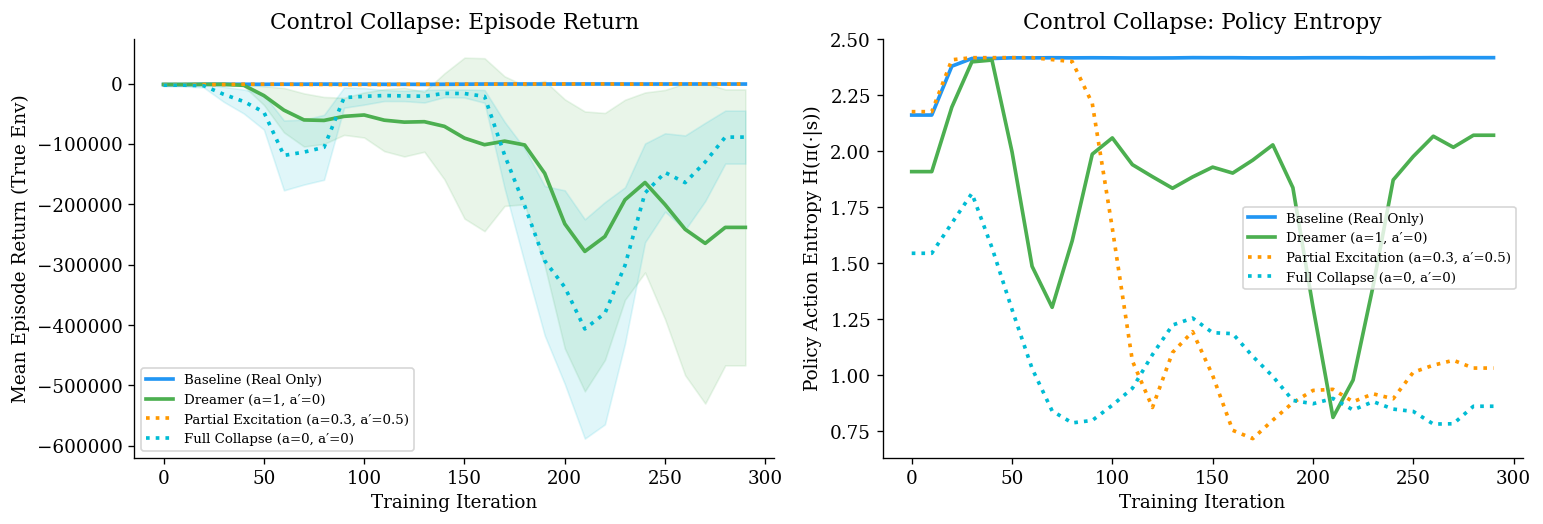

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for label, res in all_results.items():
    logs = res['logs']
    iters = np.array(logs['iteration'])
    ret   = smooth(np.array(logs['eval_return']))
    std   = smooth(np.array(logs['eval_return_std']))
    ax.plot(iters, ret, color=res['color'], ls=res['linestyle'], lw=2.2, label=label)
    ax.fill_between(iters, ret - std, ret + std, color=res['color'], alpha=0.12)
ax.set_xlabel('Training Iteration')
ax.set_ylabel('Mean Episode Return (True Env)')
ax.set_title('Control Collapse: Episode Return')
ax.legend(fontsize=8)

ax = axes[1]
for label, res in all_results.items():
    logs = res['logs']
    ax.plot(logs['iteration'], smooth(logs['policy_entropy']),
            color=res['color'], ls=res['linestyle'], lw=2.2, label=label)
ax.set_xlabel('Training Iteration')
ax.set_ylabel('Policy Action Entropy H(π(·|s))')
ax.set_title('Control Collapse: Policy Entropy')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
